In [1]:
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline") 
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())  

inline


<xarray.Dataset> Size: 9MB
Dimensions:      (time: 348, lat: 51, lon: 41)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1997-01-01T00:30:00 ... 2025-12-01...
  * lat          (lat) float64 408B 25.0 25.5 26.0 26.5 ... 48.5 49.0 49.5 50.0
  * lon          (lon) float64 328B -90.0 -89.38 -88.75 ... -66.25 -65.62 -65.0
Data variables:
    NET_TOA_CLR  (time, lat, lon) float32 3MB ...
    NET_SFC_CLR  (time, lat, lon) float32 3MB ...
    TS           (time, lat, lon) float32 3MB ...
Attributes:
    title:             MERRA-2 Eastern US clear-sky net TOA flux, net surface...
    source_directory:  /scratch/sjacker2/project_data
    note:              NET_TOA_CLR = SWTNTCLR - LWTUPCLR; NET_SFC_CLR = SWGNT...
<xarray.Dataset> Size: 6kB
Dimensions:    (time: 348)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1997-01-01 1997-02-01 ... 2025-12-01
Data variables:
    PM25_mean  (time) float64 3kB ...
Attributes:
    pm25_formula:            PM2.5_dry = DUSMASS25 + SSSMASS25 + BC

/tmp/ipykernel_954080/901204286.py:290: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(
/tmp/ipykernel_954080/901204286.py:388: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  ax.legend(


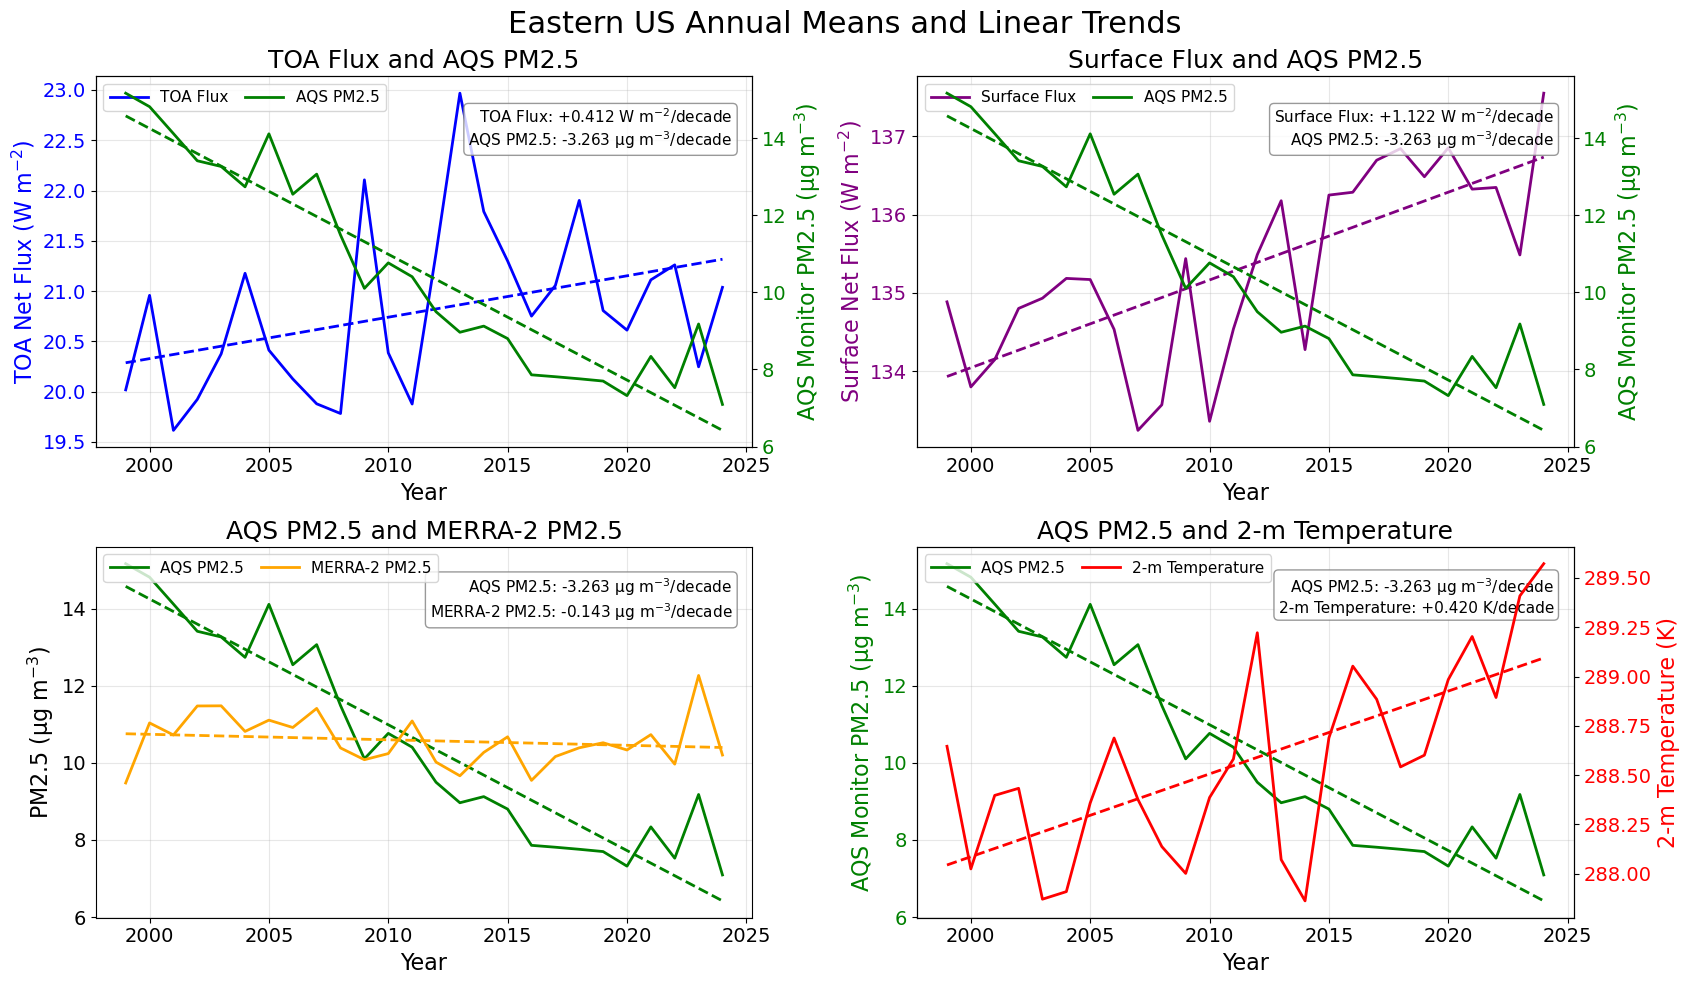

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_eastern_us_fluxes_ts_combined.nc"
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_monitor_cells_eastern_us_monthly.nc"
temp_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means_DRY.nc"

# This is the combined monthly monitor file created from AQS AirData daily CSVs
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"

# -----------------------------
# Open MERRA-2 datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_file)
ds_temp = xr.open_dataset(temp_file)

# Restrict to common period
start_date = "1997-01-01"
end_date = "2025-12-31"

ds_flux = ds_flux.sel(time=slice(start_date, end_date))
ds_pm = ds_pm.sel(time=slice(start_date, end_date))
ds_temp = ds_temp.sel(time=slice(start_date, end_date))

print(ds_flux)
print(ds_pm)

# -----------------------------
# Area-weight MERRA-2 fluxes
# -----------------------------
weights = np.cos(np.deg2rad(ds_flux["lat"]))
weights.name = "weights"

toa_ts = ds_flux["NET_TOA_CLR"].weighted(weights).mean(dim=("lat", "lon"))
sfc_ts = ds_flux["NET_SFC_CLR"].weighted(weights).mean(dim=("lat", "lon"))

# Already area-weighted by process_aer_slv.py
merra_pm25_ts = ds_pm["PM25_mean"]
t2m_ts = ds_temp["T2M_mean"]

# -----------------------------
# MERRA-2 annual means
# -----------------------------
toa_annual = toa_ts.groupby("time.year").mean()
sfc_annual = sfc_ts.groupby("time.year").mean()
merra_pm25_annual = merra_pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

# -----------------------------
# Read monthly AQS monitor PM2.5 data
# -----------------------------
mon = pd.read_csv(monitor_file)

print(mon.head())
print(mon.columns)

# Make sure year/month are numeric
mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")

# Make sure PM2.5 monthly mean is numeric
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")

# Drop missing values
mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"])

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

# Restrict to analysis years
mon = mon[(mon["year"] >= 1997) & (mon["year"] <= 2025)].copy()

# -----------------------------
# Optional completeness filter
# -----------------------------
# If you want to require at least some number of daily observations per monitor-month,
# change this value. Keep it low at first because many PM2.5 monitors sampled every 3rd/6th day.
MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

# -----------------------------
# Compute eastern U.S. monitor monthly mean
# -----------------------------
# This first averages across all monitors available in each month.
# This means the regional monthly value is the mean of monitor-month values.
monitor_monthly_region = (
    mon
    .groupby(["year", "month"], as_index=False)
    .agg(
        monitor_pm25_mean=("monthly_pm25_mean", "mean"),
        n_monitors=("monitor_id", "nunique") if "monitor_id" in mon.columns else ("monthly_pm25_mean", "count"),
        n_monitor_months=("monthly_pm25_mean", "count")
    )
)

# -----------------------------
# Compute annual monitor mean
# -----------------------------
# This averages the 12 regional monthly means to avoid over-weighting months with more monitors.
monitor_annual_df = (
    monitor_monthly_region
    .groupby("year", as_index=False)
    .agg(
        monitor_pm25_annual=("monitor_pm25_mean", "mean"),
        mean_n_monitors=("n_monitors", "mean"),
        n_months=("monitor_pm25_mean", "count")
    )
)

# Optional: require all 12 months for annual mean
# Comment this out if you want to keep partial years.
monitor_annual_df = monitor_annual_df[monitor_annual_df["n_months"] == 12].copy()

print("\nMonitor annual means:")
print(monitor_annual_df.head())
print(monitor_annual_df.tail())

# -----------------------------
# Align all datasets to common years
# -----------------------------
years_merra = toa_annual["year"].values.astype(int)
years_monitor = monitor_annual_df["year"].values.astype(int)

common_years = np.intersect1d(years_merra, years_monitor)

# Keep only common years
toa_annual_common = toa_annual.sel(year=common_years)
sfc_annual_common = sfc_annual.sel(year=common_years)
merra_pm25_annual_common = merra_pm25_annual.sel(year=common_years)
t2m_annual_common = t2m_annual.sel(year=common_years)

monitor_annual_common = (
    monitor_annual_df
    .set_index("year")
    .loc[common_years, "monitor_pm25_annual"]
)

years = common_years.astype(float)

toa_vals = toa_annual_common.values
sfc_vals = sfc_annual_common.values
merra_pm25_vals = merra_pm25_annual_common.values
t2m_vals = t2m_annual_common.values
monitor_pm25_vals = monitor_annual_common.values

# -----------------------------
# Trend helper
# -----------------------------
def fit_trend(years, values):
    """
    Returns slope, intercept, and trendline.
    Automatically removes NaNs.
    """
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)

    return coeffs, trendline


# -----------------------------
# Fit linear trends
# -----------------------------
toa_coeffs, toa_trendline = fit_trend(years, toa_vals)
sfc_coeffs, sfc_trendline = fit_trend(years, sfc_vals)
merra_pm25_coeffs, merra_pm25_trendline = fit_trend(years, merra_pm25_vals)
t2m_coeffs, t2m_trendline = fit_trend(years, t2m_vals)
monitor_pm25_coeffs, monitor_pm25_trendline = fit_trend(years, monitor_pm25_vals)
# -----------------------------
# Trend per decade
# -----------------------------
toa_trend_decade = toa_coeffs[0] * 10
sfc_trend_decade = sfc_coeffs[0] * 10
monitor_pm25_trend_decade = monitor_pm25_coeffs[0] * 10
merra_pm25_trend_decade = merra_pm25_coeffs[0] * 10
t2m_trend_decade = t2m_coeffs[0] * 10

# -----------------------------
# Print trends
# -----------------------------
print("\nAnnual-mean trends")
print("------------------")
print(f"Years used: {int(years.min())}-{int(years.max())}")
print(f"Number of years: {len(years)}")
print()

print(f"TOA flux:             {toa_coeffs[0]:.4f} W m^-2/year")
print(f"TOA flux:             {toa_trend_decade:.4f} W m^-2/decade")
print()

print(f"Surface flux:         {sfc_coeffs[0]:.4f} W m^-2/year")
print(f"Surface flux:         {sfc_trend_decade:.4f} W m^-2/decade")
print()

print(f"AQS monitor PM2.5:    {monitor_pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"AQS monitor PM2.5:    {monitor_pm25_trend_decade:.4f} µg m^-3/decade")
print()

print(f"MERRA-2 PM2.5:        {merra_pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"MERRA-2 PM2.5:        {merra_pm25_trend_decade:.4f} µg m^-3/decade")
print()

print(f"T2M:                  {t2m_coeffs[0]:.4f} K/year")
print(f"T2M:                  {t2m_trend_decade:.4f} K/decade")


# -----------------------------
# Plot helper
# -----------------------------
def make_dual_panel(
    ax,
    years,
    left_data,
    left_trend,
    right_data,
    right_trend,
    left_axis_label,
    right_axis_label,
    left_legend_label,
    right_legend_label,
    left_color,
    right_color,
    title,
    left_trend_decade,
    right_trend_decade,
    left_units,
    right_units
):
    # Left axis
    l1 = ax.plot(
        years,
        left_data,
        color=left_color,
        linewidth=2,
        label=left_legend_label
    )

    l2 = ax.plot(
        years,
        left_trend,
        color=left_color,
        linestyle="--",
        linewidth=2
    )

    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(left_axis_label, fontsize=16, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True, alpha=0.3)

    # Right axis
    axr = ax.twinx()

    l3 = axr.plot(
        years,
        right_data,
        color=right_color,
        linewidth=2,
        label=right_legend_label
    )

    l4 = axr.plot(
        years,
        right_trend,
        color=right_color,
        linestyle="--",
        linewidth=2
    )

    axr.set_ylabel(right_axis_label, fontsize=16, color=right_color)
    axr.tick_params(axis="y", labelcolor=right_color, labelsize=14)

    # Combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]

    ax.legend(
        lines,
        labels,
        loc="upper left",
        frameon=True,
        fontsize=11,
        ncol=2,
        columnspacing=1.1,
        handlelength=2.5
    )

    # Bottom-right trend text box
    trend_text = (
        f"{left_legend_label}: {left_trend_decade:+.3f} {left_units}/decade\n"
        f"{right_legend_label}: {right_trend_decade:+.3f} {right_units}/decade"
    )

    ax.text(
        0.97,
        0.92,
        trend_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    ax.set_title(title, fontsize=18)

# -----------------------------
# Plot helper for same-unit variables
# -----------------------------
def make_single_axis_panel(
    ax,
    years,
    data1,
    trend1,
    data2,
    trend2,
    y_axis_label,
    label1,
    label2,
    color1,
    color2,
    title,
    trend1_decade,
    trend2_decade,
    units
):
    # First variable
    l1 = ax.plot(
        years,
        data1,
        color=color1,
        linewidth=2,
        label=label1
    )

    l2 = ax.plot(
        years,
        trend1,
        color=color1,
        linestyle="--",
        linewidth=2
    )

    # Second variable
    l3 = ax.plot(
        years,
        data2,
        color=color2,
        linewidth=2,
        label=label2
    )

    l4 = ax.plot(
        years,
        trend2,
        color=color2,
        linestyle="--",
        linewidth=2
    )

    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(y_axis_label, fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.3)

    # Combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]

    ax.legend(
        lines,
        labels,
        loc="upper left",
        frameon=True,
        fontsize=11,
        ncol=2,
        columnspacing=1.1,
        handlelength=2.5
    )

    # Top-right trend text box
    trend_text = (
        f"{label1}: {trend1_decade:+.3f} {units}/decade\n"
        f"{label2}: {trend2_decade:+.3f} {units}/decade"
    )

    ax.text(
        0.97,
        0.92,
        trend_text,
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8,
            edgecolor="gray"
        )
    )

    ax.set_title(title, fontsize=18)
# -----------------------------
# Create 4-panel figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

# Panel 1: TOA flux and PM2.5 monitors
make_dual_panel(
    axes[0, 0],
    years,
    toa_vals,
    toa_trendline,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    "TOA Net Flux (W m$^{-2}$)",
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "TOA Flux",
    "AQS PM2.5",
    "blue",
    "green",
    "TOA Flux and AQS PM2.5",
    toa_trend_decade,
    monitor_pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 2: Surface flux and PM2.5 monitors
make_dual_panel(
    axes[0, 1],
    years,
    sfc_vals,
    sfc_trendline,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    "Surface Net Flux (W m$^{-2}$)",
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "Surface Flux",
    "AQS PM2.5",
    "purple",
    "green",
    "Surface Flux and AQS PM2.5",
    sfc_trend_decade,
    monitor_pm25_trend_decade,
    "W m$^{-2}$",
    "µg m$^{-3}$"
)

# Panel 3: PM2.5 monitors and MERRA-2 PM2.5
# Panel 3: PM2.5 monitors and MERRA-2 PM2.5
# Same units, so use one shared y-axis
make_single_axis_panel(
    axes[1, 0],
    years,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    merra_pm25_vals,
    merra_pm25_trendline,
    "PM2.5 (µg m$^{-3}$)",
    "AQS PM2.5",
    "MERRA-2 PM2.5",
    "green",
    "orange",
    "AQS PM2.5 and MERRA-2 PM2.5",
    monitor_pm25_trend_decade,
    merra_pm25_trend_decade,
    "µg m$^{-3}$"
)

# Panel 4: PM2.5 monitors and T2M
make_dual_panel(
    axes[1, 1],
    years,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    t2m_vals,
    t2m_trendline,
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "2-m Temperature (K)",
    "AQS PM2.5",
    "2-m Temperature",
    "green",
    "red",
    "AQS PM2.5 and 2-m Temperature",
    monitor_pm25_trend_decade,
    t2m_trend_decade,
    "µg m$^{-3}$",
    "K"
)

plt.suptitle("Eastern US Annual Means and Linear Trends", fontsize=22)
plt.tight_layout()
plt.show()

   year  month  monitor_pm25  n_monitors  n_monitor_months  merra_pm25  \
0  1999      1     16.325708         347               347    8.355498   
1  1999      2     15.406885         404               404    8.436576   
2  1999      3     12.057941         433               433    8.482208   
3  1999      4     11.924857         458               458    9.830909   
4  1999      5     14.639716         458               458   10.312016   

        date  
0 1999-01-01  
1 1999-02-01  
2 1999-03-01  
3 1999-04-01  
4 1999-05-01  
     year  month  monitor_pm25  n_monitors  n_monitor_months  merra_pm25  \
318  2025      7      9.826479         515               517   14.697273   
319  2025      8      8.709455         456               457   13.507978   
320  2025      9      7.843699         342               342   10.047547   
321  2025     10      5.419866          49                50    7.739618   
322  2025     11      5.159233           3                 3    7.410837   

        

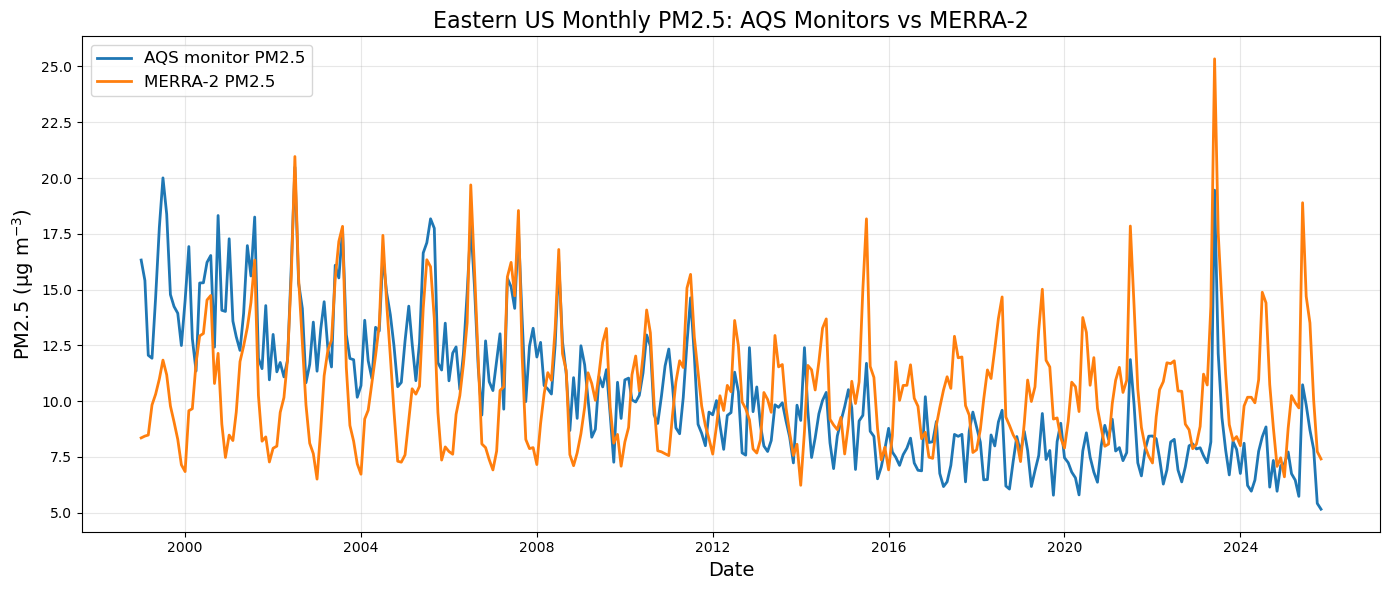

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_monitor_cells_eastern_us_monthly.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"

# -----------------------------
# Open MERRA-2 monthly PM2.5
# -----------------------------
ds_pm = xr.open_dataset(pm25_file)

# Already regional mean from your process_aer_slv.py
merra_pm25 = ds_pm["PM25_mean"]

# Convert to dataframe
merra_df = merra_pm25.to_dataframe(name="merra_pm25").reset_index()
merra_df["time"] = pd.to_datetime(merra_df["time"])
merra_df["year"] = merra_df["time"].dt.year
merra_df["month"] = merra_df["time"].dt.month

# -----------------------------
# Read monitor monthly PM2.5
# -----------------------------
mon = pd.read_csv(monitor_file)

mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")

mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"]).copy()
mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

# Optional monthly completeness filter
MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

# -----------------------------
# Compute eastern US monitor monthly regional mean
# -----------------------------
monitor_monthly = (
    mon
    .groupby(["year", "month"], as_index=False)
    .agg(
        monitor_pm25=("monthly_pm25_mean", "mean"),
        n_monitors=("monitor_id", "nunique") if "monitor_id" in mon.columns else ("monthly_pm25_mean", "count"),
        n_monitor_months=("monthly_pm25_mean", "count")
    )
)

# -----------------------------
# Merge MERRA-2 and monitor monthly data
# -----------------------------
df = pd.merge(
    monitor_monthly,
    merra_df[["year", "month", "merra_pm25"]],
    on=["year", "month"],
    how="inner"
)

df = df.sort_values(["year", "month"]).reset_index(drop=True)

# Create datetime for plotting
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1)
)

print(df.head())
print(df.tail())
print(f"Number of matched months: {len(df)}")

# -----------------------------
# Correlation and bias
# -----------------------------
r = df["monitor_pm25"].corr(df["merra_pm25"])
bias = (df["merra_pm25"] - df["monitor_pm25"]).mean()
rmse = np.sqrt(((df["merra_pm25"] - df["monitor_pm25"]) ** 2).mean())

print("\nMonthly comparison")
print("------------------")
print(f"Pearson r: {r:.3f}")
print(f"Mean bias, MERRA-2 - monitors: {bias:.3f} µg m^-3")
print(f"RMSE: {rmse:.3f} µg m^-3")

# -----------------------------
# Time series plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df["date"],
    df["monitor_pm25"],
    linewidth=2,
    label="AQS monitor PM2.5"
)

ax.plot(
    df["date"],
    df["merra_pm25"],
    linewidth=2,
    label="MERRA-2 PM2.5"
)

ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_title("Eastern US Monthly PM2.5: AQS Monitors vs MERRA-2", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


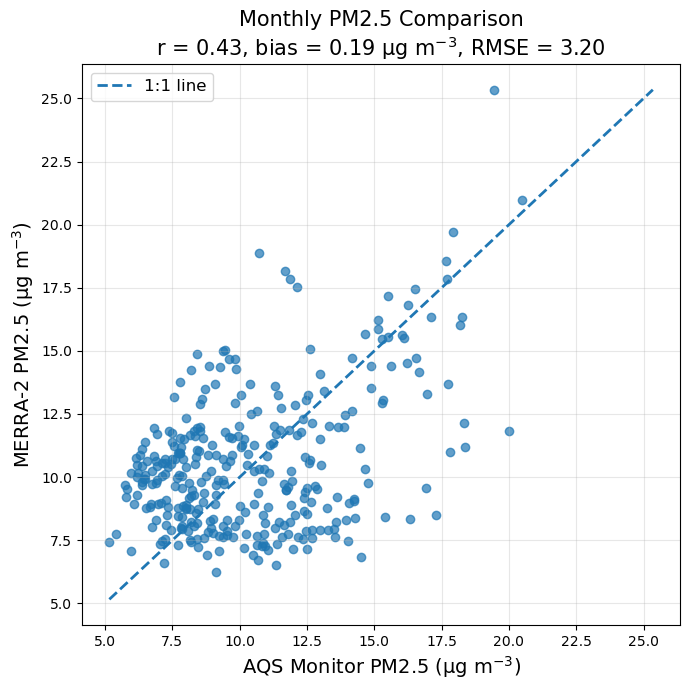

In [4]:
# -----------------------------
# Scatter plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    df["monitor_pm25"],
    df["merra_pm25"],
    alpha=0.7
)

# 1:1 line
min_val = min(df["monitor_pm25"].min(), df["merra_pm25"].min())
max_val = max(df["monitor_pm25"].max(), df["merra_pm25"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="1:1 line"
)

ax.set_xlabel("AQS Monitor PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_ylabel("MERRA-2 PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_title(
    f"Monthly PM2.5 Comparison\nr = {r:.2f}, bias = {bias:.2f} µg m$^{{-3}}$, RMSE = {rmse:.2f}",
    fontsize=15
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

<xarray.Dataset> Size: 9MB
Dimensions:      (time: 348, lat: 51, lon: 41)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1997-01-01T00:30:00 ... 2025-12-01...
  * lat          (lat) float64 408B 25.0 25.5 26.0 26.5 ... 48.5 49.0 49.5 50.0
  * lon          (lon) float64 328B -90.0 -89.38 -88.75 ... -66.25 -65.62 -65.0
Data variables:
    NET_TOA_CLR  (time, lat, lon) float32 3MB ...
    NET_SFC_CLR  (time, lat, lon) float32 3MB ...
    TS           (time, lat, lon) float32 3MB ...
Attributes:
    title:             MERRA-2 Eastern US clear-sky net TOA flux, net surface...
    source_directory:  /scratch/sjacker2/project_data
    note:              NET_TOA_CLR = SWTNTCLR - LWTUPCLR; NET_SFC_CLR = SWGNT...
<xarray.Dataset> Size: 6kB
Dimensions:                     (time: 348)
Coordinates:
  * time                        (time) datetime64[ns] 3kB 1997-01-01 ... 2025...
Data variables:
    PM25_wet_monitor_cell_mean  (time) float64 3kB ...
Attributes:
    pm25_formula:            P

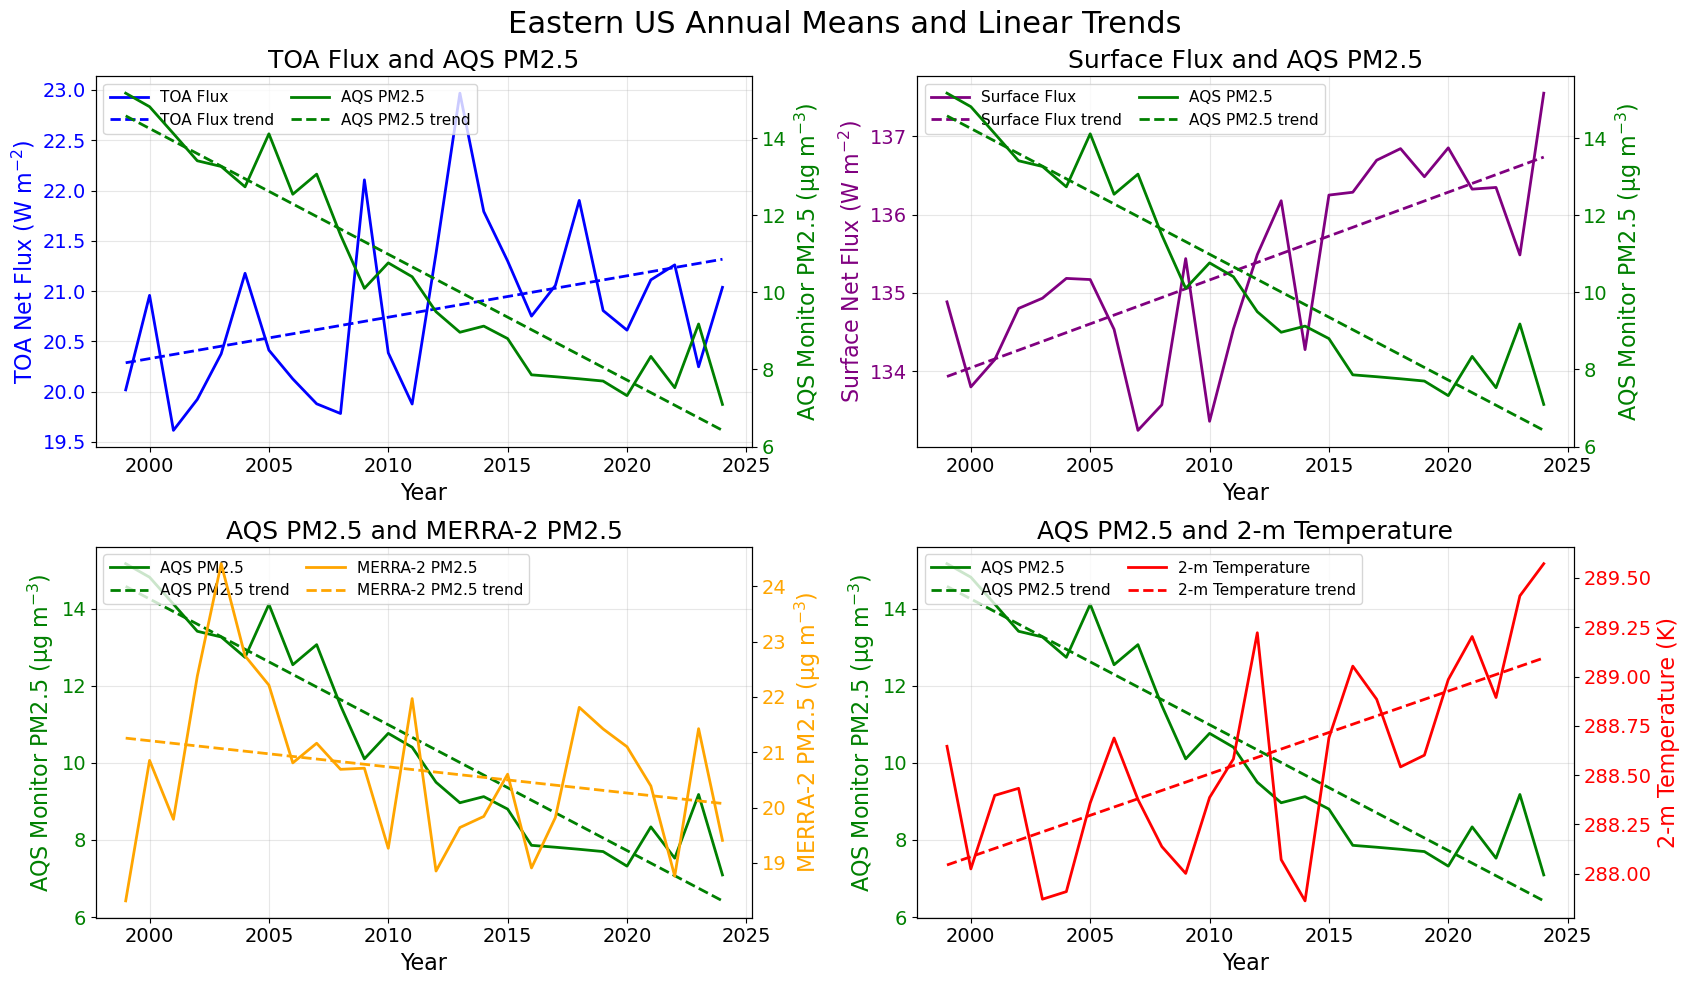

In [14]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_eastern_us_fluxes_ts_combined.nc"
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_wet_monitor_cells_eastern_us_monthly.nc"
temp_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means_DRY.nc"

# This is the combined monthly monitor file created from AQS AirData daily CSVs
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"

# -----------------------------
# Open MERRA-2 datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_file)
ds_temp = xr.open_dataset(temp_file)

# Restrict to common period
start_date = "1997-01-01"
end_date = "2025-12-31"

ds_flux = ds_flux.sel(time=slice(start_date, end_date))
ds_pm = ds_pm.sel(time=slice(start_date, end_date))
ds_temp = ds_temp.sel(time=slice(start_date, end_date))

print(ds_flux)
print(ds_pm)

# -----------------------------
# Area-weight MERRA-2 fluxes
# -----------------------------
weights = np.cos(np.deg2rad(ds_flux["lat"]))
weights.name = "weights"

toa_ts = ds_flux["NET_TOA_CLR"].weighted(weights).mean(dim=("lat", "lon"))
sfc_ts = ds_flux["NET_SFC_CLR"].weighted(weights).mean(dim=("lat", "lon"))

# Already area-weighted by process_aer_slv.py
merra_pm25_ts = ds_pm["PM25_wet_monitor_cell_mean"]
t2m_ts = ds_temp["T2M_mean"]

# -----------------------------
# MERRA-2 annual means
# -----------------------------
toa_annual = toa_ts.groupby("time.year").mean()
sfc_annual = sfc_ts.groupby("time.year").mean()
merra_pm25_annual = merra_pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

# -----------------------------
# Read monthly AQS monitor PM2.5 data
# -----------------------------
mon = pd.read_csv(monitor_file)

print(mon.head())
print(mon.columns)

# Make sure year/month are numeric
mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")

# Make sure PM2.5 monthly mean is numeric
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")

# Drop missing values
mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"])

mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

# Restrict to analysis years
mon = mon[(mon["year"] >= 1997) & (mon["year"] <= 2025)].copy()

# -----------------------------
# Optional completeness filter
# -----------------------------
# If you want to require at least some number of daily observations per monitor-month,
# change this value. Keep it low at first because many PM2.5 monitors sampled every 3rd/6th day.
MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

# -----------------------------
# Compute eastern U.S. monitor monthly mean
# -----------------------------
# This first averages across all monitors available in each month.
# This means the regional monthly value is the mean of monitor-month values.
monitor_monthly_region = (
    mon
    .groupby(["year", "month"], as_index=False)
    .agg(
        monitor_pm25_mean=("monthly_pm25_mean", "mean"),
        n_monitors=("monitor_id", "nunique") if "monitor_id" in mon.columns else ("monthly_pm25_mean", "count"),
        n_monitor_months=("monthly_pm25_mean", "count")
    )
)

# -----------------------------
# Compute annual monitor mean
# -----------------------------
# This averages the 12 regional monthly means to avoid over-weighting months with more monitors.
monitor_annual_df = (
    monitor_monthly_region
    .groupby("year", as_index=False)
    .agg(
        monitor_pm25_annual=("monitor_pm25_mean", "mean"),
        mean_n_monitors=("n_monitors", "mean"),
        n_months=("monitor_pm25_mean", "count")
    )
)

# Optional: require all 12 months for annual mean
# Comment this out if you want to keep partial years.
monitor_annual_df = monitor_annual_df[monitor_annual_df["n_months"] == 12].copy()

print("\nMonitor annual means:")
print(monitor_annual_df.head())
print(monitor_annual_df.tail())

# -----------------------------
# Align all datasets to common years
# -----------------------------
years_merra = toa_annual["year"].values.astype(int)
years_monitor = monitor_annual_df["year"].values.astype(int)

common_years = np.intersect1d(years_merra, years_monitor)

# Keep only common years
toa_annual_common = toa_annual.sel(year=common_years)
sfc_annual_common = sfc_annual.sel(year=common_years)
merra_pm25_annual_common = merra_pm25_annual.sel(year=common_years)
t2m_annual_common = t2m_annual.sel(year=common_years)

monitor_annual_common = (
    monitor_annual_df
    .set_index("year")
    .loc[common_years, "monitor_pm25_annual"]
)

years = common_years.astype(float)

toa_vals = toa_annual_common.values
sfc_vals = sfc_annual_common.values
merra_pm25_vals = merra_pm25_annual_common.values
t2m_vals = t2m_annual_common.values
monitor_pm25_vals = monitor_annual_common.values

# -----------------------------
# Trend helper
# -----------------------------
def fit_trend(years, values):
    """
    Returns slope, intercept, and trendline.
    Automatically removes NaNs.
    """
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)

    coeffs = np.polyfit(years[mask], values[mask], 1)
    trendline = np.polyval(coeffs, years)

    return coeffs, trendline


# -----------------------------
# Fit linear trends
# -----------------------------
toa_coeffs, toa_trendline = fit_trend(years, toa_vals)
sfc_coeffs, sfc_trendline = fit_trend(years, sfc_vals)
merra_pm25_coeffs, merra_pm25_trendline = fit_trend(years, merra_pm25_vals)
t2m_coeffs, t2m_trendline = fit_trend(years, t2m_vals)
monitor_pm25_coeffs, monitor_pm25_trendline = fit_trend(years, monitor_pm25_vals)

# -----------------------------
# Print trends
# -----------------------------
print("\nAnnual-mean trends")
print("------------------")
print(f"Years used: {int(years.min())}-{int(years.max())}")
print(f"Number of years: {len(years)}")
print()

print(f"TOA flux:             {toa_coeffs[0]:.4f} W m^-2/year")
print(f"TOA flux:             {toa_coeffs[0] * 10:.4f} W m^-2/decade")
print()

print(f"Surface flux:         {sfc_coeffs[0]:.4f} W m^-2/year")
print(f"Surface flux:         {sfc_coeffs[0] * 10:.4f} W m^-2/decade")
print()

print(f"AQS monitor PM2.5:    {monitor_pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"AQS monitor PM2.5:    {monitor_pm25_coeffs[0] * 10:.4f} µg m^-3/decade")
print()

print(f"MERRA-2 PM2.5:        {merra_pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"MERRA-2 PM2.5:        {merra_pm25_coeffs[0] * 10:.4f} µg m^-3/decade")
print()

print(f"T2M:                  {t2m_coeffs[0]:.4f} K/year")
print(f"T2M:                  {t2m_coeffs[0] * 10:.4f} K/decade")


# -----------------------------
# Plot helper
# -----------------------------
def make_dual_panel(
    ax,
    years,
    left_data,
    left_trend,
    right_data,
    right_trend,
    left_axis_label,
    right_axis_label,
    left_legend_label,
    right_legend_label,
    left_color,
    right_color,
    title
):
    # Left axis
    l1 = ax.plot(
        years,
        left_data,
        color=left_color,
        linewidth=2,
        label=left_legend_label
    )

    l2 = ax.plot(
        years,
        left_trend,
        color=left_color,
        linestyle="--",
        linewidth=2,
        label=f"{left_legend_label} trend"
    )

    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(left_axis_label, fontsize=16, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True, alpha=0.3)

    # Right axis
    axr = ax.twinx()

    l3 = axr.plot(
        years,
        right_data,
        color=right_color,
        linewidth=2,
        label=right_legend_label
    )

    l4 = axr.plot(
        years,
        right_trend,
        color=right_color,
        linestyle="--",
        linewidth=2,
        label=f"{right_legend_label} trend"
    )

    axr.set_ylabel(right_axis_label, fontsize=16, color=right_color)
    axr.tick_params(axis="y", labelcolor=right_color, labelsize=14)

    # Combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]

    ax.legend(
        lines,
        labels,
        loc="upper left",
        frameon=True,
        fontsize=11,
        ncol=2,
        columnspacing=1.1,
        handlelength=2.5
    )

    ax.set_title(title, fontsize=18)


# -----------------------------
# Create 4-panel figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

# Panel 1: TOA flux and PM2.5 monitors
make_dual_panel(
    axes[0, 0],
    years,
    toa_vals,
    toa_trendline,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    "TOA Net Flux (W m$^{-2}$)",
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "TOA Flux",
    "AQS PM2.5",
    "blue",
    "green",
    "TOA Flux and AQS PM2.5"
)

# Panel 2: Surface flux and PM2.5 monitors
make_dual_panel(
    axes[0, 1],
    years,
    sfc_vals,
    sfc_trendline,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    "Surface Net Flux (W m$^{-2}$)",
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "Surface Flux",
    "AQS PM2.5",
    "purple",
    "green",
    "Surface Flux and AQS PM2.5"
)

# Panel 3: PM2.5 monitors and MERRA-2 PM2.5
make_dual_panel(
    axes[1, 0],
    years,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    merra_pm25_vals,
    merra_pm25_trendline,
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "MERRA-2 PM2.5 (µg m$^{-3}$)",
    "AQS PM2.5",
    "MERRA-2 PM2.5",
    "green",
    "orange",
    "AQS PM2.5 and MERRA-2 PM2.5"
)

# Panel 4: PM2.5 monitors and T2M
make_dual_panel(
    axes[1, 1],
    years,
    monitor_pm25_vals,
    monitor_pm25_trendline,
    t2m_vals,
    t2m_trendline,
    "AQS Monitor PM2.5 (µg m$^{-3}$)",
    "2-m Temperature (K)",
    "AQS PM2.5",
    "2-m Temperature",
    "green",
    "red",
    "AQS PM2.5 and 2-m Temperature"
)

plt.suptitle("Eastern US Annual Means and Linear Trends", fontsize=22)
plt.tight_layout()
plt.show()

   year  month  monitor_pm25  n_monitors  n_monitor_months  merra_pm25  \
0  1999      1     16.325708         347               347   26.271670   
1  1999      2     15.406885         404               404   21.712428   
2  1999      3     12.057941         433               433   16.328626   
3  1999      4     11.924857         458               458   18.267435   
4  1999      5     14.639716         458               458   16.414709   

        date  
0 1999-01-01  
1 1999-02-01  
2 1999-03-01  
3 1999-04-01  
4 1999-05-01  
     year  month  monitor_pm25  n_monitors  n_monitor_months  merra_pm25  \
318  2025      7      9.826479         515               517   22.940066   
319  2025      8      8.709455         456               457   19.890498   
320  2025      9      7.843699         342               342   14.855374   
321  2025     10      5.419866          49                50   13.120152   
322  2025     11      5.159233           3                 3   13.263279   

        

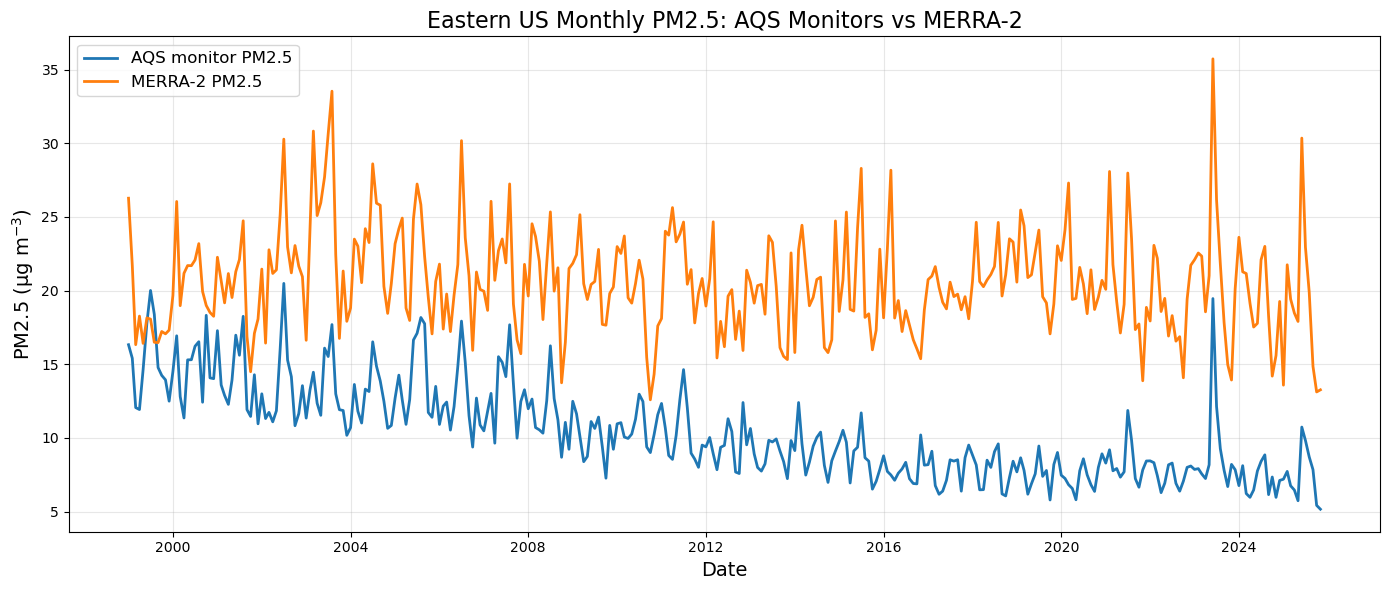

In [9]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_wet_monitor_cells_eastern_us_monthly.nc"
monitor_file = "/scratch/sjacker2/project_data/monthly_pm25_eastern_us_1999_2025.csv"

# -----------------------------
# Open MERRA-2 monthly PM2.5
# -----------------------------
ds_pm = xr.open_dataset(pm25_file)

# Already regional mean from your process_aer_slv.py
merra_pm25 = ds_pm["PM25_wet_monitor_cell_mean"]

# Convert to dataframe
merra_df = merra_pm25.to_dataframe(name="merra_pm25").reset_index()
merra_df["time"] = pd.to_datetime(merra_df["time"])
merra_df["year"] = merra_df["time"].dt.year
merra_df["month"] = merra_df["time"].dt.month

# -----------------------------
# Read monitor monthly PM2.5
# -----------------------------
mon = pd.read_csv(monitor_file)

mon["year"] = pd.to_numeric(mon["year"], errors="coerce")
mon["month"] = pd.to_numeric(mon["month"], errors="coerce")
mon["monthly_pm25_mean"] = pd.to_numeric(mon["monthly_pm25_mean"], errors="coerce")

mon = mon.dropna(subset=["year", "month", "monthly_pm25_mean"]).copy()
mon["year"] = mon["year"].astype(int)
mon["month"] = mon["month"].astype(int)

# Optional monthly completeness filter
MIN_DAILY_VALUES = 1

if "n_daily_values" in mon.columns:
    mon = mon[mon["n_daily_values"] >= MIN_DAILY_VALUES].copy()

# -----------------------------
# Compute eastern US monitor monthly regional mean
# -----------------------------
monitor_monthly = (
    mon
    .groupby(["year", "month"], as_index=False)
    .agg(
        monitor_pm25=("monthly_pm25_mean", "mean"),
        n_monitors=("monitor_id", "nunique") if "monitor_id" in mon.columns else ("monthly_pm25_mean", "count"),
        n_monitor_months=("monthly_pm25_mean", "count")
    )
)

# -----------------------------
# Merge MERRA-2 and monitor monthly data
# -----------------------------
df = pd.merge(
    monitor_monthly,
    merra_df[["year", "month", "merra_pm25"]],
    on=["year", "month"],
    how="inner"
)

df = df.sort_values(["year", "month"]).reset_index(drop=True)

# Create datetime for plotting
df["date"] = pd.to_datetime(
    dict(year=df["year"], month=df["month"], day=1)
)

print(df.head())
print(df.tail())
print(f"Number of matched months: {len(df)}")

# -----------------------------
# Correlation and bias
# -----------------------------
r = df["monitor_pm25"].corr(df["merra_pm25"])
bias = (df["merra_pm25"] - df["monitor_pm25"]).mean()
rmse = np.sqrt(((df["merra_pm25"] - df["monitor_pm25"]) ** 2).mean())

print("\nMonthly comparison")
print("------------------")
print(f"Pearson r: {r:.3f}")
print(f"Mean bias, MERRA-2 - monitors: {bias:.3f} µg m^-3")
print(f"RMSE: {rmse:.3f} µg m^-3")

# -----------------------------
# Time series plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df["date"],
    df["monitor_pm25"],
    linewidth=2,
    label="AQS monitor PM2.5"
)

ax.plot(
    df["date"],
    df["merra_pm25"],
    linewidth=2,
    label="MERRA-2 PM2.5"
)

ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_title("Eastern US Monthly PM2.5: AQS Monitors vs MERRA-2", fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

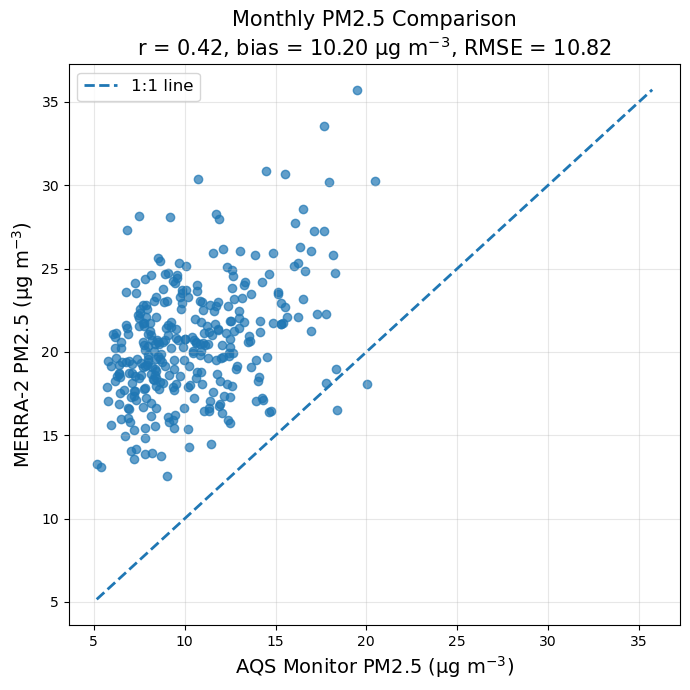

In [10]:
# -----------------------------
# Scatter plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    df["monitor_pm25"],
    df["merra_pm25"],
    alpha=0.7
)

# 1:1 line
min_val = min(df["monitor_pm25"].min(), df["merra_pm25"].min())
max_val = max(df["monitor_pm25"].max(), df["merra_pm25"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="1:1 line"
)

ax.set_xlabel("AQS Monitor PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_ylabel("MERRA-2 PM2.5 (µg m$^{-3}$)", fontsize=14)
ax.set_title(
    f"Monthly PM2.5 Comparison\nr = {r:.2f}, bias = {bias:.2f} µg m$^{{-3}}$, RMSE = {rmse:.2f}",
    fontsize=15
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()